In [ ]:
!wget ait-rami.github.io/PRED_TRAFFIC.zip
!unzip PRED_TRAFFIC.zip > /dev/null

URL transformed to HTTPS due to an HSTS policy
--2021-06-02 22:59:38--  https://ait-rami.github.io/PRED_TRAFFIC.zip
Resolving ait-rami.github.io (ait-rami.github.io)... 185.199.109.153, 185.199.110.153, 185.199.108.153, ...
Connecting to ait-rami.github.io (ait-rami.github.io)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10656077 (10M) [application/zip]
Saving to: ‘PRED_TRAFFIC.zip.1’

PRED_TRAFFIC.zip.1  100%[===================>]  10.16M  28.7MB/s    in 0.4s    

2021-06-02 22:59:39 (28.7 MB/s) - ‘PRED_TRAFFIC.zip.1’ saved [10656077/10656077]

replace PRED_TRAFFIC/Codes_LOT2_cloud/ACF_fft.m? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
!ls PRED_TRAFFIC/nb_variable_utilisateurs/scenario1
!head PRED_TRAFFIC/nb_variable_utilisateurs/scenario1/rx_throughput.csv

global_stats.txt   rx_throughput.txt  tx_throughput.txt
rx_throughput.csv  tx_throughput.csv
time;throughput (kbps)
20.1;0
20.2;0
20.3;0
20.4;0
20.5;0
20.6;0
20.7;0
20.8;0
20.9;0


In [ ]:
# https://machinelearningmastery.com/autoregression-models-time-series-forecasting-python/

In [ ]:
!pip install pip install statsmodels --upgrade

       throughput (kbps)
count       71999.000000
mean        35707.407635
std          9690.308741
min             0.000000
25%         28809.550000
50%         34620.300000
75%         41494.350000
max         90174.600000


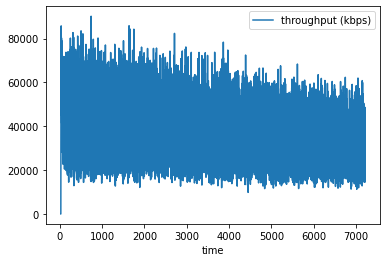

In [ ]:
from sklearn import svm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error
series = pd.read_csv('PRED_TRAFFIC/nb_variable_utilisateurs/scenario1/rx_throughput.csv', sep = ';', header=0, index_col=0)
print(series.describe())
series.plot()
plt.show()

RBF model Test MSE: 65642043.315


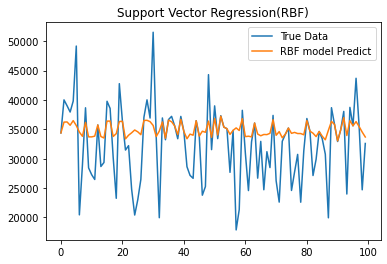

In [ ]:
def data_pre(data):
    """
    :param data: 
    :param seq_len: 
    :return: 
    """
    row = round(0.9 * data.shape[0])
    data = data.values
    train = data[:int(row), :]
    x_train = train[:, :]
    y_train = train[:,0]
    x_test = data[int(row):, :]
    y_test = data[int(row):, 0]
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1]))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1]))
    return [x_train, y_train, x_test, y_test]

df = pd.read_csv('PRED_TRAFFIC/nb_variable_utilisateurs/scenario1/rx_throughput.csv', sep = ';', header=0, index_col=0)
X_train, y_train, X_test, y_test = data_pre(df)
svr_rbf = svm.SVR(kernel='rbf', C=1e2, gamma=0.1)
svr_rbf.fit(X_train,y_train)
p1 = svr_rbf.predict(X_test)

error = mean_squared_error(y_test, p1)
print('RBF model Test MSE: %.3f' % error)


plt.plot(y_test[0: 100], label='True Data')
plt.plot(p1[0: 100], label='RBF model Predict')
plt.title('Support Vector Regression(RBF)')
plt.legend()
plt.show()

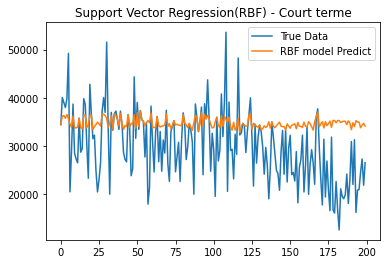

In [ ]:

plt.plot(y_test[0:200], label='True Data')
plt.plot(p1[0:200], label='RBF model Predict')
plt.title('Support Vector Regression(RBF) - Court terme')
plt.legend()
plt.figure(1).patch.set_facecolor("white")
plt.show()


POLY model Test MSE: 3187859.132


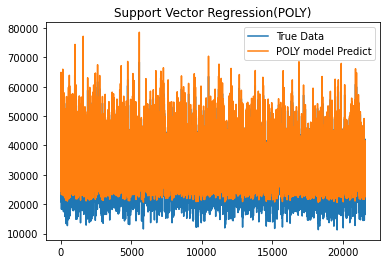

In [ ]:
def data_pre(data):
    """
    :param data: 
    :param seq_len: 
    :return: 
    """
    row = round(0.7 * data.shape[0])
    data = data.values
    train = data[:int(row), :]
    x_train = train[:, :]
    y_train = train[:,0]
    x_test = data[int(row):, :]
    y_test = data[int(row):, 0]
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1]))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1]))
    return [x_train, y_train, x_test, y_test]

df = pd.read_csv('PRED_TRAFFIC/nb_variable_utilisateurs/scenario1/rx_throughput.csv', sep = ';', header=0, index_col=0)
X_train, y_train, X_test, y_test = data_pre(df)
svr_poly = svm.SVR(kernel='poly', C=1e2, degree=2)
#svr_rbf = svm.SVR(kernel='rbf', C=1e2, gamma=0.1)
svr_poly.fit(X_train,y_train)
#svr_rbf.fit(X_train,y_train)
p1 = svr_poly.predict(X_test)
#p3 = svr_rbf.predict(X_test)

error = mean_squared_error(y_test, p1)
print('POLY model Test MSE: %.3f' % error)


plt.plot(y_test, label='True Data')
plt.plot(p1, label='POLY model Predict')
plt.title('Support Vector Regression(POLY)')
plt.legend()
plt.show()

In [ ]:
import math
error = math.sqrt(mean_squared_error(y_test, p1))
print('POLY model Test MSE: %.3f' % error)

plt.plot(y_test[5000:5100], label='True Data')
plt.plot(p1[5000:5100], label='POLY model Predict')
plt.title('Support Vector Regression(POLY) - Long terme')
plt.legend()
plt.figure(1).patch.set_facecolor("white")
plt.show()

NameError: ignored

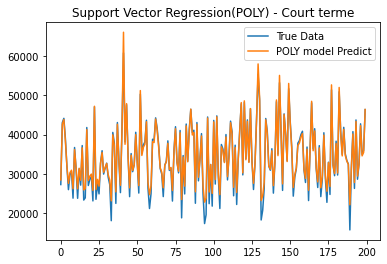

In [ ]:
plt.plot(y_test[100:300], label='True Data')
plt.plot(p1[100:300], label='POLY model Predict')
plt.title('Support Vector Regression(POLY) - Court terme')
plt.legend()
plt.figure(1).patch.set_facecolor("white")
plt.show()